<a href="https://colab.research.google.com/github/banteamlak1888/ML_project_2025/blob/main/ML_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###**TF-IDF (Term Frequency-Inverse Document Frequency)**

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
import xgboost as xgb
from sklearn.naive_bayes import MultinomialNB # Import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier # Import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
# Step 1: Load the dataset

from google.colab import drive
drive.mount("/content/drive", force_remount=True)
data= pd.read_csv('/content/drive/MyDrive/Colab_Notebooks/ML_NLP/Normalized_Data.csv')
data.drop(columns=['URL','Source'], inplace=True)


Mounted at /content/drive


In [ ]:
#X = data.drop('Category', axis = 1)
#y = data['Category']
#X.shape, y.shape
                # OR
# Step 2: Prepare features (X) and target (y)
# Assuming the last column is the target class and the first 5 columns are textual features
X = data.iloc[:, :-1]  # Select all columns except the last as features
y = data.iloc[:, -1]   # Select the last column as the target

In [ ]:
# Step 3: Combine textual features into a single text string per row
X_text = X.astype(str).agg(' '.join, axis=1)

In [ ]:
# Step 4: Split the dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X_text, y, test_size=0.2, random_state=42)

In [ ]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((4320,), (1080,), (4320,), (1080,))

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)  # Limit features for efficiency
X_tfidf = vectorizer.fit_transform(X)  # Transform text data into numerical form


###**Models**

####**Grid Search Algorithm**

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# Create Pipeline
pipeline_knn = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('knn', KNeighborsClassifier())
])

# Define Hyperparameter Grid
param_grid_knn = {
    'knn__n_neighbors': [3, 5, 7, 10],
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan', 'cosine']
}

# Grid Search
grid_search_knn = GridSearchCV(pipeline_knn, param_grid_knn, cv=5, verbose=2, n_jobs=-1)
grid_search_knn.fit(X_train, y_train)

# Best Parameters
print("Best Parameters for KNN:", grid_search_knn.best_params_)


Fitting 5 folds for each of 24 candidates, totalling 120 fits


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [0.78263889 0.80324074 0.78171296 0.81018519 0.7849537  0.81851852
 0.78472222 0.81944444        nan 0.16365741        nan 0.16388889
        nan 0.16388889        nan 0.16388889 0.78263889 0.80509259
 0.78171296 0.81296296 0.7849537  0.82106481 0.78472222 0.8224537 ]
  warnings.warn(


Best Parameters for KNN: {'knn__metric': 'cosine', 'knn__n_neighbors': 10, 'knn__weights': 'distance'}


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

# Create Pipeline
pipeline_dt = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('dt', DecisionTreeClassifier(random_state=42))
])

# Define Hyperparameter Grid
param_grid_dt = {
    'dt__max_depth': [10, 50, 100],
    'dt__min_samples_split': [2, 5, 10],
    'dt__min_samples_leaf': [1, 2, 5],
    'dt__class_weight': [None, 'balanced']
}

# Grid Search
grid_search_dt = GridSearchCV(pipeline_dt, param_grid_dt, cv=5, verbose=2, n_jobs=-1)
grid_search_dt.fit(X_train, y_train)

# Best Parameters
print("Best Parameters for DT:", grid_search_dt.best_params_)


Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best Parameters for DT: {'dt__class_weight': 'balanced', 'dt__max_depth': 100, 'dt__min_samples_leaf': 1, 'dt__min_samples_split': 2}


In [ ]:
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import GridSearchCV

# Create Pipeline
pipeline_svm = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('svm', SVC())
])

# Define Hyperparameter Grid
param_grid_svm = {
    'svm__C': [0.1, 1, 10, 100],  # Regularization parameter
    'svm__kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
    'svm__gamma': ['scale', 'auto']
}

# Grid Search
grid_search_svm = GridSearchCV(pipeline_svm, param_grid_svm, cv=5, verbose=2, n_jobs=-1)
grid_search_svm.fit(X_train, y_train)

# Best Parameters
print("Best Parameters for SVM:", grid_search_svm.best_params_)


Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best Parameters for SVM: {'svm__C': 10, 'svm__gamma': 'scale', 'svm__kernel': 'linear'}


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import GridSearchCV

# Create Pipeline
pipeline_rf = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('rf', RandomForestClassifier(random_state=42))
])

# Define Hyperparameter Grid
param_grid_rf = {
    'rf__n_estimators': [50, 100, 200],  # Number of trees
    'rf__max_depth': [None, 10, 20, 30],  # Depth of trees
    'rf__min_samples_split': [2, 5, 10],
    'rf__min_samples_leaf': [1, 2, 4]
}

# Grid Search
grid_search_rf = GridSearchCV(pipeline_rf, param_grid_rf, cv=5, verbose=2, n_jobs=-1)
grid_search_rf.fit(X_train, y_train)

# Best Parameters
print("Best Parameters for RF:", grid_search_rf.best_params_)


In [ ]:
from sklearn.naive_bayes import MultinomialNB

# Create Pipeline
pipeline_nb = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english', smooth_idf=True)),
    ('nb', MultinomialNB())
])

# Define Hyperparameter Grid
param_grid_nb = {
    'nb__alpha': [0.1, 0.5, 1, 5, 10]  # Alpha controls smoothing
}

# Grid Search
grid_search_nb = GridSearchCV(pipeline_nb, param_grid_nb, cv=10, verbose=2, n_jobs=-1)
grid_search_nb.fit(X_train, y_train)

# Best Parameters
print("Best Parameters for NB:", grid_search_nb.best_params_)


Fitting 10 folds for each of 5 candidates, totalling 50 fits
Best Parameters for NB: {'nb__alpha': 0.1}


####**Model Eval**

In [ ]:
# Step 5: Define pipelines for Random Forest, Decision Tree, KNN, SVM, and Naive Bayes models
# The pipeline includes text vectorization (TF-IDF) and the classifier

rf_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),  # Convert text into numerical form
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42))  # Train a Random Forest model
])

dt_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),  # Convert text into numerical form
    ('dt', DecisionTreeClassifier(random_state=42))  # Train a Decision Tree model
])

knn_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),  # Convert text into numerical form
    ('knn', KNeighborsClassifier(n_neighbors=6))  # Train a KNN model
])

svm_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),  # Convert text into numerical form
    ('svm', SVC(random_state=42))  # Train a Support Vector Machine model
])

nb_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),  # Convert text into numerical form
    ('nb', MultinomialNB())  # Train a Naive Bayes model
])

In [ ]:

# Step 6: Train and evaluate the Random Forest model
print('Training and evaluating Random Forest model...')
rf_pipeline.fit(X_train, y_train)  # Train the model
rf_train_accuracy = accuracy_score(y_train, rf_pipeline.predict(X_train))
y_pred_rf = rf_pipeline.predict(X_test)  # Predict on test data
rf_test_accuracy = accuracy_score(y_test, y_pred_rf)
print('Random Forest Model Results:')
print(f'Training Accuracy: {rf_train_accuracy:.4f}')
print(f'Testing Accuracy: {rf_test_accuracy:.4f}')
print(classification_report(y_test, y_pred_rf))

Training and evaluating Random Forest model...
Random Forest Model Results:
Training Accuracy: 0.9692
Testing Accuracy: 0.8472
              precision    recall  f1-score   support

         ART       0.95      0.96      0.96       192
    Business       0.79      0.69      0.74       167
      Health       0.86      0.90      0.88       176
       Other       0.82      0.69      0.75       198
    Politics       0.74      0.87      0.80       174
       Sport       0.91      0.97      0.94       173

    accuracy                           0.85      1080
   macro avg       0.85      0.85      0.84      1080
weighted avg       0.85      0.85      0.84      1080



In [ ]:
# Step 7: Train and evaluate the Decision Tree model
print('Training and evaluating Decision Tree model...')
dt_pipeline.fit(X_train, y_train)  # Train the model
dt_train_accuracy = accuracy_score(y_train, dt_pipeline.predict(X_train))
y_pred_dt = dt_pipeline.predict(X_test)  # Predict on test data
dt_test_accuracy = accuracy_score(y_test, y_pred_dt)
print('Decision Tree Model Results:')
print(f'Training Accuracy: {dt_train_accuracy:.4f}')
print(f'Testing Accuracy: {dt_test_accuracy:.4f}')
print(classification_report(y_test, y_pred_dt))

Training and evaluating Decision Tree model...
Decision Tree Model Results:
Training Accuracy: 0.9829
Testing Accuracy: 0.7083
              precision    recall  f1-score   support

         ART       0.83      0.86      0.85       192
    Business       0.57      0.60      0.59       167
      Health       0.78      0.78      0.78       176
       Other       0.54      0.53      0.53       198
    Politics       0.68      0.62      0.65       174
       Sport       0.85      0.86      0.85       173

    accuracy                           0.71      1080
   macro avg       0.71      0.71      0.71      1080
weighted avg       0.71      0.71      0.71      1080



In [ ]:
# Step 8: Train and evaluate the K-Nearest Neighbors model
print('Training and evaluating K-Nearest Neighbors model...')
knn_pipeline.fit(X_train, y_train)  # Train the model
knn_train_accuracy = accuracy_score(y_train, knn_pipeline.predict(X_train))
y_pred_knn = knn_pipeline.predict(X_test)  # Predict on test data
knn_test_accuracy = accuracy_score(y_test, y_pred_knn)
print('K-Nearest Neighbors Model Results:')
print(f'Training Accuracy: {knn_train_accuracy:.4f}')
print(f'Testing Accuracy: {knn_test_accuracy:.4f}')
print(classification_report(y_test, y_pred_knn))

Training and evaluating K-Nearest Neighbors model...
K-Nearest Neighbors Model Results:
Training Accuracy: 0.9829
Testing Accuracy: 0.8157
              precision    recall  f1-score   support

         ART       0.92      0.95      0.93       192
    Business       0.70      0.69      0.70       167
      Health       0.78      0.86      0.82       176
       Other       0.83      0.60      0.70       198
    Politics       0.73      0.84      0.78       174
       Sport       0.93      0.95      0.94       173

    accuracy                           0.82      1080
   macro avg       0.82      0.82      0.81      1080
weighted avg       0.82      0.82      0.81      1080



In [ ]:
# Step 9: Train and evaluate the Support Vector Machine (SVM) model
print('Training and evaluating Support Vector Machine model...')
svm_pipeline.fit(X_train, y_train)  # Train the model
svm_train_accuracy = accuracy_score(y_train, svm_pipeline.predict(X_train))
y_pred_svm = svm_pipeline.predict(X_test)  # Predict on test data
svm_test_accuracy = accuracy_score(y_test, y_pred_svm)
print('Support Vector Machine Model Results:')
print(f'Training Accuracy: {svm_train_accuracy:.4f}')
print(f'Testing Accuracy: {svm_test_accuracy:.4f}')
print(classification_report(y_test, y_pred_svm))

Training and evaluating Support Vector Machine model...
Support Vector Machine Model Results:
Training Accuracy: 0.9609
Testing Accuracy: 0.8630
              precision    recall  f1-score   support

         ART       0.95      0.97      0.96       192
    Business       0.80      0.75      0.78       167
      Health       0.90      0.90      0.90       176
       Other       0.80      0.77      0.78       198
    Politics       0.78      0.85      0.82       174
       Sport       0.95      0.93      0.94       173

    accuracy                           0.86      1080
   macro avg       0.86      0.86      0.86      1080
weighted avg       0.86      0.86      0.86      1080



In [ ]:
# Step 10: Train and evaluate the Naive Bayes model
print('Training and evaluating Naive Bayes model...')
nb_pipeline.fit(X_train, y_train)  # Train the model
nb_train_accuracy = accuracy_score(y_train, nb_pipeline.predict(X_train))
y_pred_nb = nb_pipeline.predict(X_test)  # Predict on test data
nb_test_accuracy = accuracy_score(y_test, y_pred_nb)
print('Naive Bayes Model Results:')
print(f'Training Accuracy: {nb_train_accuracy:.4f}')
print(f'Testing Accuracy: {nb_test_accuracy:.4f}')
print(classification_report(y_test, y_pred_nb))

Training and evaluating Naive Bayes model...
Naive Bayes Model Results:
Training Accuracy: 0.9470
Testing Accuracy: 0.8630
              precision    recall  f1-score   support

         ART       0.95      0.98      0.96       192
    Business       0.82      0.70      0.75       167
      Health       0.84      0.93      0.88       176
       Other       0.90      0.69      0.78       198
    Politics       0.73      0.93      0.82       174
       Sport       0.95      0.96      0.96       173

    accuracy                           0.86      1080
   macro avg       0.87      0.86      0.86      1080
weighted avg       0.87      0.86      0.86      1080



In [ ]:
X = ["በሙስሊሞች ዘንድ ዋነኛው የፆም ወቅት ረመዳን ነው። በዚህ ወቅትም በተወሰኑ ሁኔታዎች ውስጥ ካሉት የእምነቱ ተከታዮች ውጪ ሁሉም ሙስሊሞች መፆም ይጠበቅባቸዋል።\
የረመዳን ወር የእስልምና ቅዱስ መጽሐፍ የሆነው ቁርዓን ለነብዩ መሐመድ የተገለጠበትን ጊዜ የሚዘክር ነው።\
በእስልምና አምስት አምዶች አንዱ የሆነው የረመዳን ወር በፆም እና በፀሎት የሚታሰብ ሲሆን፣ ሕዝበ ሙስሊሙ ይህን ወር የእምነቱን ሥርዓት ጠብቆ እንዲያሳልፈው ይጠበቃል።\
የረመዳንን ወር በፆም ፀሎት የሚያስቡ ሙስሊሞች ጎህ ከመቅደዱ በፊት ሱሁር አሊያም ሴህሪ የተሰኘ ማዕድ በመቅመስ ቀናቸውን ይጀምራሉ።\
በመልካም ጤንነት ላይ ሰዎች ፆሙን ሳያጓድሉ እንዲያስቡ ይጠበቃል። በህመም ላይ ያሉ፣ ዕድሜያቸው ያልደረሰ ልጆች፣ ነፍሰጡሮች፣ የሚያጠቡ እናቶች፣ የወር አበባ እያዩ ያሉ እና ተጓዦች ፆሙን ጊዜ ጠብቀው ላያካሂዱት ይችላሉ።\
አንዳንድ ሰዎች ፆሙ ቀላል ሊሆንላቸው ይችላል፤ አንዳንዶች ደግሞ የቀን ተቀን ሥራቸውን እያከናወኑ ሳለ አፋቸው እህል ጣል አድርጉብን የሚል ስሜት ሊያመጣባቸው ይችላል።\
እና የረመዳን ወርን በፆም ለማሰብ ምን ዓይነት ምግቦችን መመገብ፤ የትኞችንስ ማስወገድ አለብን?"]

In [ ]:
#rf_pipeline.predict(X)
#dt_pipeline.predict(X)
#knn_pipeline.predict(X)
#svm_pipeline.predict(X)
nb_pipeline.predict(X)

array(['Health'], dtype='<U8')

###**Comparision of Model results**

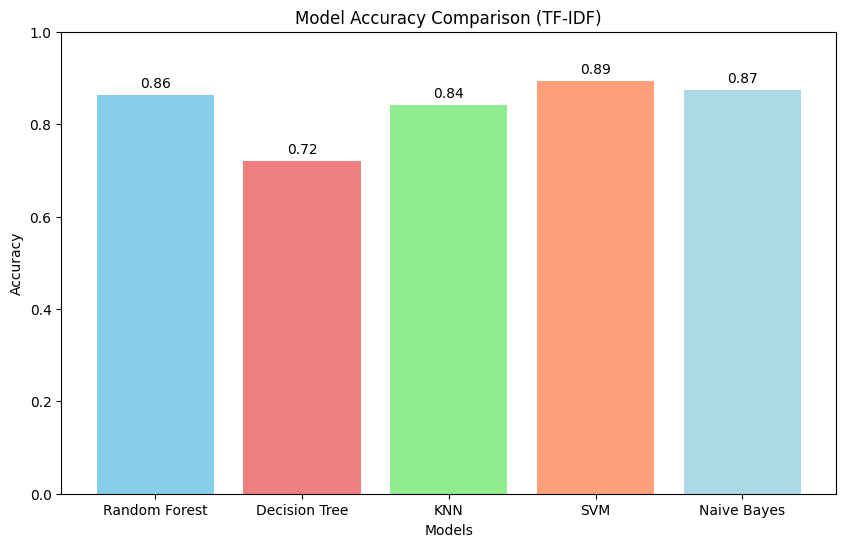

In [ ]:
# prompt: compare the above 5 algorithms and plot

import matplotlib.pyplot as plt

# Accuracy values from the previous code execution
rf_test_accuracy = 0.8628
dt_test_accuracy = 0.7197
knn_test_accuracy = 0.8410
svm_test_accuracy = 0.8926
nb_test_accuracy = 0.8728


models = ['Random Forest', 'Decision Tree', 'KNN', 'SVM', 'Naive Bayes']
accuracies = [rf_test_accuracy, dt_test_accuracy, knn_test_accuracy, svm_test_accuracy, nb_test_accuracy]

plt.figure(figsize=(10, 6))
plt.bar(models, accuracies, color=['skyblue', 'lightcoral', 'lightgreen', 'lightsalmon', 'lightblue'])
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison (TF-IDF)")

# Add accuracy values on top of each bar
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.01, str(round(v, 2)), ha='center', va='bottom')

plt.ylim(0, 1)  # Set y-axis limit to 0-1 for accuracy
plt.show()


###**BOW (Bag of Words)**

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
import xgboost as xgb
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
# Step 1: Load the dataset

from google.colab import drive
drive.mount("/content/drive", force_remount=True)
data= pd.read_csv('/content/drive/MyDrive/Colab_Notebooks/ML_NLP/Normalized_Data.csv')
data.drop(columns=['URL','Source'], inplace=True)


Mounted at /content/drive


In [ ]:
#X = data.drop('Category', axis = 1)
#y = data['Category']
#X.shape, y.shape
                # OR
# Step 2: Prepare features (X) and target (y)
# Assuming the last column is the target class and the first 5 columns are textual features
X = data.iloc[:, :-1]  # Select all columns except the last as features
y = data.iloc[:, -1]   # Select the last column as the target

In [ ]:
# Assuming your dataset has columns named 'Headline' and 'Content'
documents = (data['Headline'].astype(str) + ' ' + data['Content'].astype(str)).values
# Combine 'Headline' and 'Content' columns into a single text

In [ ]:
# Step 3: Combine textual features into a single text string per row
X_text = X.astype(str).agg(' '.join, axis=1)

In [ ]:
# Step 4: Split the dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X_text, y, test_size=0.2, random_state=42)

In [ ]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((4320,), (1080,), (4320,), (1080,))

In [ ]:
# Initialize CountVectorizer with max 5000 features
vectorizer = CountVectorizer(max_features=5000)

# Assuming your dataset has columns named 'Headline' and 'Content'
documents = (data['Headline'].astype(str) + ' ' + data['Content'].astype(str)).values

# Fit and transform the text data
X_bow = vectorizer.fit_transform(documents)  # Fit and transform on the combined text data

# Convert BoW matrix to array (if you need it as a dense array)
bow_array = X_bow.toarray()

# Get feature names (words)
feature_names = vectorizer.get_feature_names_out()

# Display results
print("BoW Feature Matrix Shape:", bow_array.shape)  # (num_samples, 5000)
print("First 20 Vocabulary Words:", feature_names[:20])

# Now split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_bow, y, test_size=0.3, random_state=42)

BoW Feature Matrix Shape: (5400, 5000)
First 20 Vocabulary Words: ['ሀላንድ' 'ሀላፊ' 'ሀላፊነቱን' 'ሀላፊነት' 'ሀላፊው' 'ሀላፊዎች' 'ሀሙስ' 'ሀማስ' 'ሀምሌ' 'ሀምሳ' 'ሀሪ'
 'ሀሪስ' 'ሀሰተኛ' 'ሀሰን' 'ሀሳቡ' 'ሀሳቡን' 'ሀሳባቸውን' 'ሀሳብ' 'ሀሳብን' 'ሀሳቦች']


###**Models**

In [ ]:
# Step 5: Define pipelines for Random Forest, Decision Tree, KNN, SVM, and Naive Bayes models
# The pipeline includes text vectorization (TF-IDF) and the classifier

rf_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),  # Convert text into numerical form
    ('rf', RandomForestClassifier(min_samples_leaf=2, min_samples_split=5, n_estimators=200, random_state=42))  # Train a Random Forest model
])

dt_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),  # Convert text into numerical form
    ('dt', DecisionTreeClassifier(class_weight= 'balanced', max_depth= 10, min_samples_leaf= 1,min_samples_split= 2, random_state=42))  # Train a Decision Tree model
])

knn_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),  # Convert text into numerical form
    ('knn', KNeighborsClassifier(n_neighbors=10, metric='cosine', weights='distance'))  # Train a KNN model
])

svm_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),  # Convert text into numerical form
    ('svm', SVC(C=1, gamma='scale', kernel='linear', random_state=42))  # Train a Support Vector Machine model
])

nb_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),  # Convert text into numerical form
    ('nb', MultinomialNB(alpha=0.1))  # Train a Naive Bayes model
])

In [ ]:
from sklearn.model_selection import cross_val_score
import numpy as np

pipelines = {
    'Random Forest': rf_pipeline,
    'Decision Tree': dt_pipeline,
    'KNN': knn_pipeline,
    'SVM': svm_pipeline,
    'Naive Bayes': nb_pipeline
}

# Assuming X contains text data and y contains labels
for model_name, pipeline in pipelines.items():
    scores = cross_val_score(pipeline, X, y, cv=10, scoring='accuracy')  # 10-fold CV
    print(f"{model_name} - Mean Accuracy: {np.mean(scores):.4f}, Std Dev: {np.std(scores):.4f}")


In [ ]:
print('Training and evaluating SVM model...')
svm_model = SVC(C=1, gamma='scale', kernel='linear', random_state=42)
svm_model.fit(X_train, y_train)
svm_preds = svm_model.predict(X_test)
print(f'Training Accuracy: {svm_train_accuracy:.4f}')
print(f'SVM Accuracy: {accuracy_score(y_test, svm_preds):.4f}')
print(classification_report(y_test, svm_preds))


Training and evaluating SVM model...
Training Accuracy: 0.9609
SVM Accuracy: 0.8210
              precision    recall  f1-score   support

         ART       0.85      0.93      0.89       272
    Business       0.69      0.75      0.72       255
      Health       0.85      0.88      0.87       264
       Other       0.79      0.75      0.77       303
    Politics       0.78      0.73      0.75       253
       Sport       0.97      0.89      0.93       273

    accuracy                           0.82      1620
   macro avg       0.82      0.82      0.82      1620
weighted avg       0.82      0.82      0.82      1620



In [ ]:
print('Training and evaluating Random Forest model...')
rf_model = RandomForestClassifier(min_samples_leaf=2, min_samples_split=5, n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)
print(f'Training Accuracy: {rf_train_accuracy:.4f}')
print(f'Testing Accuracy: {accuracy_score(y_test, rf_preds):.4f}')
print(classification_report(y_test, rf_preds))


Training and evaluating Random Forest model...
Training Accuracy: 0.9692
Testing Accuracy: 0.8494
              precision    recall  f1-score   support

         ART       0.93      0.95      0.94       272
    Business       0.77      0.69      0.73       255
      Health       0.85      0.94      0.89       264
       Other       0.83      0.71      0.76       303
    Politics       0.76      0.85      0.80       253
       Sport       0.94      0.97      0.95       273

    accuracy                           0.85      1620
   macro avg       0.85      0.85      0.85      1620
weighted avg       0.85      0.85      0.85      1620



In [ ]:
print('Training and evaluating KNN model...')
knn_model = KNeighborsClassifier(n_neighbors=10, metric='cosine', weights='distance')
knn_model.fit(X_train, y_train)
knn_preds = knn_model.predict(X_test)
print(f'Training Accuracy: {knn_train_accuracy:.4f}')
print(f'Testing Accuracy: {accuracy_score(y_test, knn_preds):.4f}')
print(classification_report(y_test, knn_preds))


Training and evaluating KNN model...
Training Accuracy: 0.9829
Testing Accuracy: 0.8043
              precision    recall  f1-score   support

         ART       0.90      0.93      0.92       272
    Business       0.67      0.71      0.69       255
      Health       0.85      0.84      0.84       264
       Other       0.80      0.63      0.71       303
    Politics       0.76      0.81      0.78       253
       Sport       0.84      0.92      0.88       273

    accuracy                           0.80      1620
   macro avg       0.80      0.81      0.80      1620
weighted avg       0.80      0.80      0.80      1620



In [ ]:
print('Training and evaluating Decision Tree model...')
dt_model = DecisionTreeClassifier(class_weight= 'balanced', max_depth= 10, min_samples_leaf= 1,min_samples_split= 2, random_state=42)
dt_model.fit(X_train, y_train)
dt_preds = dt_model.predict(X_test)
print(f'Training Accuracy: {dt_train_accuracy:.4f}')
print(f'Testing Accuracy: {accuracy_score(y_test, dt_preds):.4f}')
print(classification_report(y_test, dt_preds))


Training and evaluating Decision Tree model...
Training Accuracy: 0.6280
Testing Accuracy: 0.5883
              precision    recall  f1-score   support

         ART       0.95      0.66      0.78       272
    Business       0.83      0.31      0.45       255
      Health       0.77      0.49      0.60       264
       Other       0.33      0.85      0.48       303
    Politics       0.57      0.40      0.47       253
       Sport       0.97      0.76      0.85       273

    accuracy                           0.59      1620
   macro avg       0.74      0.58      0.60      1620
weighted avg       0.73      0.59      0.60      1620



In [ ]:
print('Training and evaluating Naive Bayes model...')
nb_model = MultinomialNB(alpha=0.1)
nb_model.fit(X_train, y_train)
nb_preds = nb_model.predict(X_test)
print(f'Training Accuracy: {nb_train_accuracy:.4f}')
print(f'Testing Accuracy: {accuracy_score(y_test, nb_preds):.4f}')
print(classification_report(y_test, nb_preds))


Training and evaluating Naive Bayes model...
Training Accuracy: 0.9470
Testing Accuracy: 0.8284
              precision    recall  f1-score   support

         ART       0.95      0.88      0.92       272
    Business       0.79      0.67      0.73       255
      Health       0.86      0.85      0.85       264
       Other       0.73      0.76      0.74       303
    Politics       0.72      0.91      0.80       253
       Sport       0.96      0.90      0.93       273

    accuracy                           0.83      1620
   macro avg       0.84      0.83      0.83      1620
weighted avg       0.84      0.83      0.83      1620



In [ ]:
X = ["በሙስሊሞች ዘንድ ዋነኛው የፆም ወቅት ረመዳን ነው። በዚህ ወቅትም በተወሰኑ ሁኔታዎች ውስጥ ካሉት የእምነቱ ተከታዮች ውጪ ሁሉም ሙስሊሞች መፆም ይጠበቅባቸዋል።\
የረመዳን ወር የእስልምና ቅዱስ መጽሐፍ የሆነው ቁርዓን ለነብዩ መሐመድ የተገለጠበትን ጊዜ የሚዘክር ነው።\
በእስልምና አምስት አምዶች አንዱ የሆነው የረመዳን ወር በፆም እና በፀሎት የሚታሰብ ሲሆን፣ ሕዝበ ሙስሊሙ ይህን ወር የእምነቱን ሥርዓት ጠብቆ እንዲያሳልፈው ይጠበቃል።\
የረመዳንን ወር በፆም ፀሎት የሚያስቡ ሙስሊሞች ጎህ ከመቅደዱ በፊት ሱሁር አሊያም ሴህሪ የተሰኘ ማዕድ በመቅመስ ቀናቸውን ይጀምራሉ።\
በመልካም ጤንነት ላይ ሰዎች ፆሙን ሳያጓድሉ እንዲያስቡ ይጠበቃል። በህመም ላይ ያሉ፣ ዕድሜያቸው ያልደረሰ ልጆች፣ ነፍሰጡሮች፣ የሚያጠቡ እናቶች፣ የወር አበባ እያዩ ያሉ እና ተጓዦች ፆሙን ጊዜ ጠብቀው ላያካሂዱት ይችላሉ።\
አንዳንድ ሰዎች ፆሙ ቀላል ሊሆንላቸው ይችላል፤ አንዳንዶች ደግሞ የቀን ተቀን ሥራቸውን እያከናወኑ ሳለ አፋቸው እህል ጣል አድርጉብን የሚል ስሜት ሊያመጣባቸው ይችላል።\
እና የረመዳን ወርን በፆም ለማሰብ ምን ዓይነት ምግቦችን መመገብ፤ የትኞችንስ ማስወገድ አለብን?"]

In [ ]:
rf_pipeline.predict(X)
#dt_pipeline.predict(X)
#knn_pipeline.predict(X)
#svm_pipeline.predict(X)
#nb_pipeline.predict(X)

array(['Other'], dtype=object)

##**Using Hyperparameter Tuning**

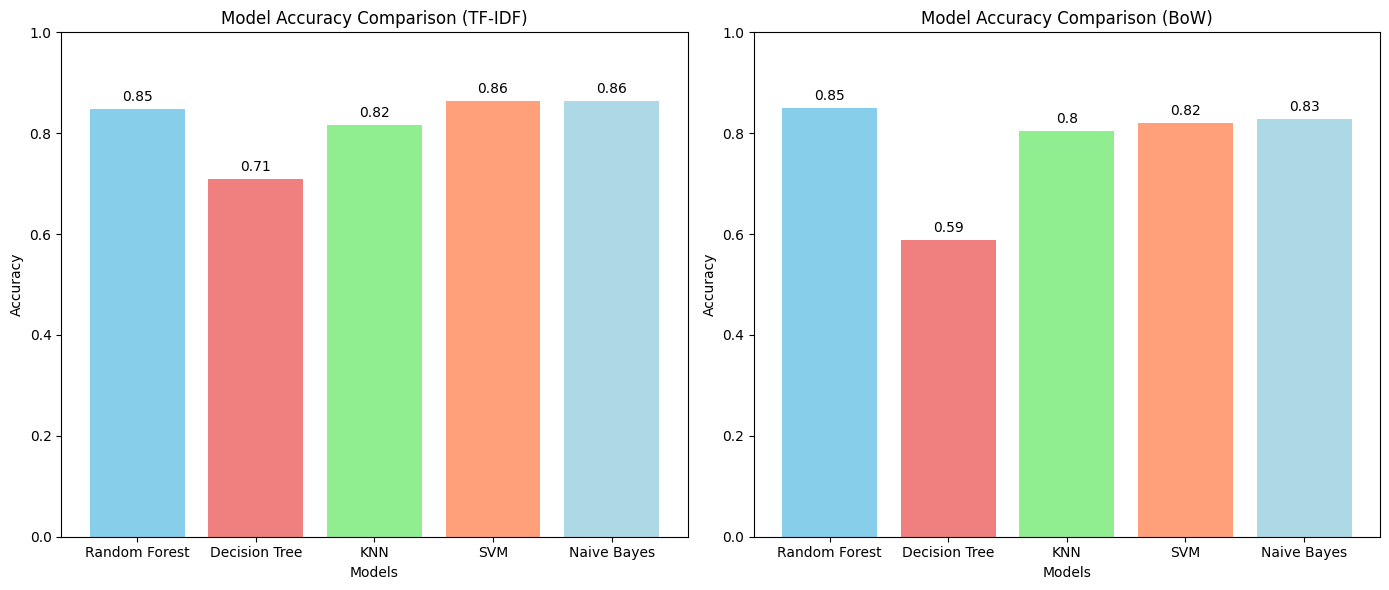

In [ ]:
import matplotlib.pyplot as plt

# First dataset (TF-IDF based model accuracies)
models_1 = ['Random Forest', 'Decision Tree', 'KNN', 'SVM', 'Naive Bayes']
accuracies_1 = [0.8472, 0.7083, 0.8157, 0.8630, 0.8630]

# Second dataset (Different evaluation scenario)
models_2 = ['Random Forest', 'Decision Tree', 'KNN', 'SVM', 'Naive Bayes']
accuracies_2 = [0.8494, 0.5883, 0.8043, 0.8210, 0.8284]

# Creating side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# First bar chart
axes[0].bar(models_1, accuracies_1, color=['skyblue', 'lightcoral', 'lightgreen', 'lightsalmon', 'lightblue'])
axes[0].set_xlabel("Models")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Model Accuracy Comparison (TF-IDF)")
axes[0].set_ylim(0, 1)

# Adding accuracy values on top of bars
for i, v in enumerate(accuracies_1):
    axes[0].text(i, v + 0.01, str(round(v, 2)), ha='center', va='bottom')

# Second bar chart
axes[1].bar(models_2, accuracies_2, color=['skyblue', 'lightcoral', 'lightgreen', 'lightsalmon', 'lightblue'])
axes[1].set_xlabel("Models")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Model Accuracy Comparison (BoW)")
axes[1].set_ylim(0, 1)

# Adding accuracy values on top of bars
for i, v in enumerate(accuracies_2):
    axes[1].text(i, v + 0.01, str(round(v, 2)), ha='center', va='bottom')

plt.tight_layout()
plt.show()
